#  EDA & FEATURE ENGINEERING TASK — HOUSE PRICES DATASET

In [2]:
# CELL 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, norm, probplot
import warnings
from sklearn.feature_selection import f_regression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

warnings.filterwarnings('ignore')


## PHASE 0 — SETUP & DATA UNDERSTANDING

- Load train.csv 
- Read the data_description.txt file fully. This dataset lives or dies on knowing what each column actually means, so don't skip this.
- Print the shape, dtypes, .head(), and .info().
- Classify every column, by hand, into a table: Numerical (continuous), Numerical (discrete/count), Ordinal (has a natural order, e.g. quality ratings), Nominal (categorical, no order), and Target.

Deliverable: A table of all ~80 columns with their type classification and a one-line meaning for each. You'll use this as your reference for the rest of the task. You should know about most of the features of the data, as they are quite self explanatory from their names.

### Section 1: Load the Data



### Section 2: Read given Data Description



### Section 2: Initial Data Inspection



In [3]:
# CELL 4: Comprehensive Data Inspection


# CELL : Load Dataset
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')


print(f"Training data: {train.shape[0]} rows × {train.shape[1]} columns")
print(f"Test data: {test.shape[0]} rows × {test.shape[1]} columns\n\n")
print("=" * 80)
print("SHAPE")
print("=" * 80)
print(f"Rows: {train.shape[0]}, Columns: {train.shape[1]}")

print("\n" + "=" * 80)
print("DATA TYPES")
print("=" * 80)
print(train.dtypes)





Training data: 1460 rows × 81 columns
Test data: 1459 rows × 80 columns


SHAPE
Rows: 1460, Columns: 81

DATA TYPES
Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object


In [4]:
print("\n\n\n" + "=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)
# pd.set_option('display.max_columns', None)
print(train.head())





FIRST 5 ROWS
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2

In [5]:

print("\n" + "=" * 80)
print("DETAILED INFO")
print("=" * 80)
print(train.info())


DETAILED INFO
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  Over

## PHASE 1 — TARGET VARIABLE ANALYSIS (SalePrice)

- Plot the distribution (histogram + KDE).
- Check skewness and kurtosis.
- Do a Q-Q plot against a normal distribution.
- Try a log1p transform and re-check the distribution/skew — compare before and after.
- Think about why regression models generally want a near-normal target.



In [6]:
# Set plot style for better visuals
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


print("=" * 80)
print("DATA LOADED")
print("=" * 80)
print(f"Training samples: {len(train)}")
print(f"SalePrice column exists: {'SalePrice' in train.columns}")

DATA LOADED
Training samples: 1460
SalePrice column exists: True


### Plot Distribution (Histogram + KDE)

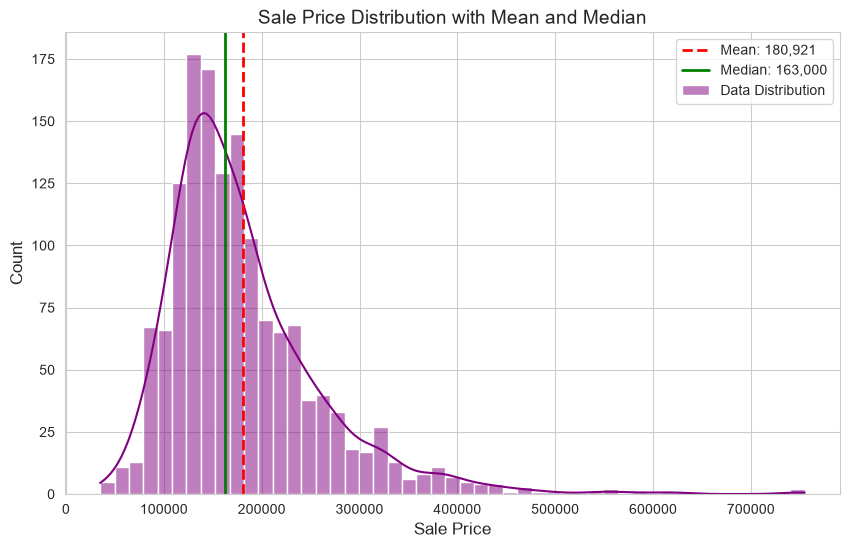

In [7]:


plt.figure(figsize=(10, 6))
# 2. Plot the histogram with the KDE curve
sns.histplot(train["SalePrice"], kde=True, color="purple", label="Data Distribution")

# 3. Calculate and add the mean line (Red dashed line)
mean_val = train["SalePrice"].mean()
plt.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:,.0f}")

# 4. Calculate and add the median line (Green solid line)
median_val = train["SalePrice"].median()
plt.axvline(median_val, color="green", linestyle="-", linewidth=2, label=f"Median: {median_val:,.0f}")

# 5. Add labels, title, and display the legend
plt.title("Sale Price Distribution with Mean and Median", fontsize=14)
plt.xlabel("Sale Price", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend()

# Show the final plot
plt.show()

### Cell 3: Check Skewness and Kurtosis


Original SalePrice Skewness : 1.881
Original SalePrice Kurtosis : 6.510


Text(0, 0.5, 'Density')

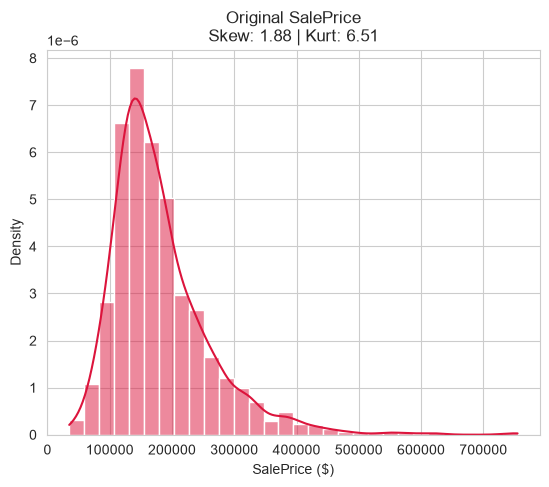

In [8]:
print("=" * 80)

# -------------------------------------------------------------
# 1. CALCULATE ORIGINAL SKEWNESS & KURTOSIS
# -------------------------------------------------------------
orig_skew = skew(train["SalePrice"])
orig_kurt = kurtosis(train["SalePrice"])

print(f"\nOriginal SalePrice Skewness : {orig_skew:.3f}")
print(f"Original SalePrice Kurtosis : {orig_kurt:.3f}")

# -------------------------------------------------------------
# 2. PLOT ORIGINAL DISTRIBUTION (Histogram + KDE)
# -------------------------------------------------------------
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(
    train["SalePrice"], kde=True, color="crimson", stat="density", bins=30
)
plt.title(
    f"Original SalePrice\nSkew: {orig_skew:.2f} | Kurt: {orig_kurt:.2f}"
)
plt.xlabel("SalePrice ($)")
plt.ylabel("Density")

### Create a Q-Q Plot
(Quantile-Quantile plot) is a diagnostic scatter plot that compares your data against a theoretical normal distribution (the perfect bell curve).

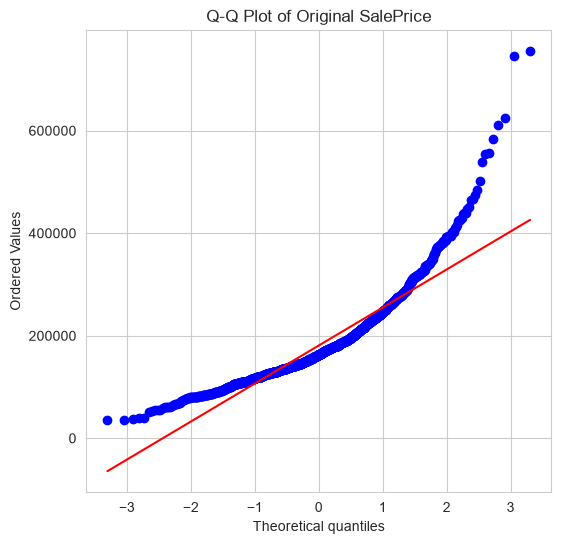

In [9]:
plt.figure(figsize=(6, 6))
stats.probplot(train["SalePrice"], plot=plt)
plt.title("Q-Q Plot of Original SalePrice")
plt.show()

### APPLY LOG1P TRANSFORM & RE-CHECK

#### Transdormation

In [10]:

# -------------------------------------------------------------
# Apply log1p transformation to safely handle values and compress outliers
train["SalePrice_Log"] = np.log1p(train["SalePrice"])

log_skew = skew(train["SalePrice_Log"])
log_kurt = kurtosis(train["SalePrice_Log"])

print(f"\nLog-Transformed Skewness : {log_skew:.3f}")
print(f"Log-Transformed Kurtosis : {log_kurt:.3f}")


Log-Transformed Skewness : 0.121
Log-Transformed Kurtosis : 0.803


#### PLOT TRANSFORMED DISTRIBUTION & Q-Q PLOT

Text(0, 0.5, 'Density')

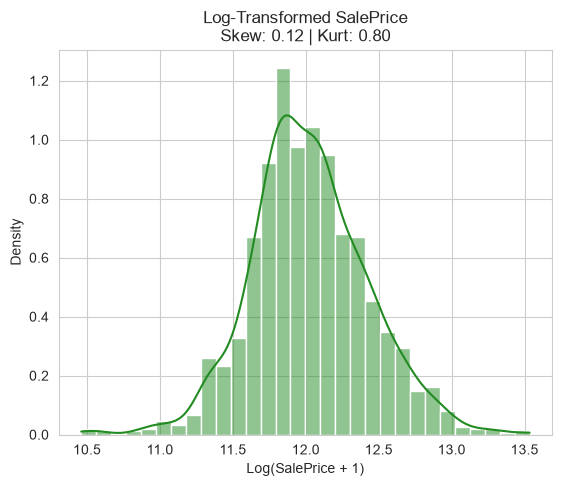

In [11]:
# -------------------------------------------------------------
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(
    train["SalePrice_Log"],
    kde=True,
    color="forestgreen",
    stat="density",
    bins=30,
)
plt.title(
    f"Log-Transformed SalePrice\nSkew: {log_skew:.2f} | Kurt: {log_kurt:.2f}"
)
plt.xlabel("Log(SalePrice + 1)")
plt.ylabel("Density")



Text(0.5, 1.0, 'Q-Q Plot: Log-Transformed SalePrice (Aligned to Normal Line)')

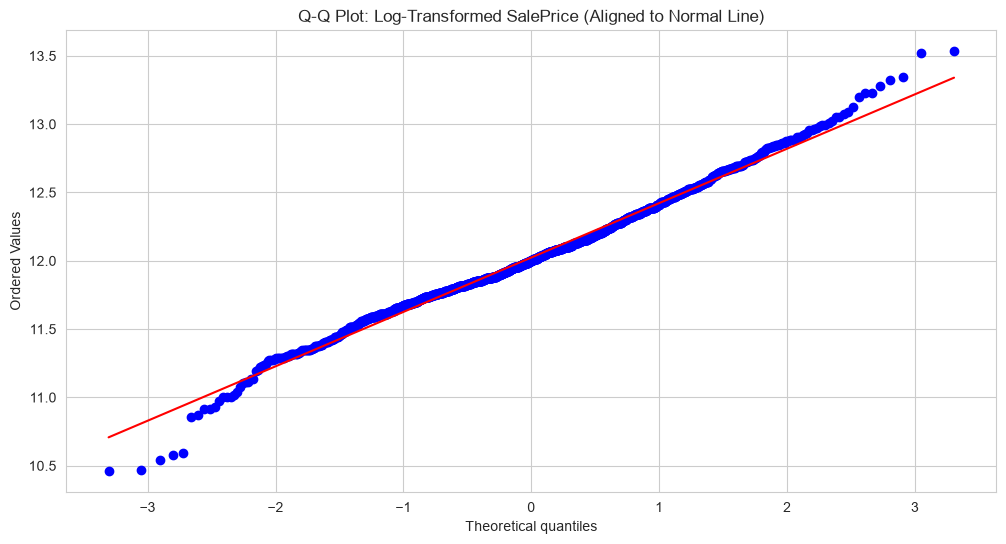

In [12]:

stats.probplot(train["SalePrice_Log"], plot=plt)
plt.title("Q-Q Plot: Log-Transformed SalePrice (Aligned to Normal Line)")


# pHASE 2 — MISSING DATA ANALYSIS

- Compute missing percentage per column, sorted descending. Visualize it (bar chart or a missingno matrix).
- For every column with missing values, figure out WHY it's missing by checking data_description.txt:
  - Structural missingness (e.g. PoolQC is NaN because there's no pool, not because the value is unknown)
  - Truly missing / unknown data
- Build a decision table: column, missing %, reason, planned treatment (fill with "None"/0, fill with median/mode, drop column, drop rows).
- Implement the treatment.


## Explanation
### STRUCTURAL MISSINGNESS  :

The value is missing BECAUSE the feature doesn't   exist for this observation.
- Also called: "Informative Missing" or "Missing by Design"
-  The MISSINGNESS ITSELF is information!

- example 
House A: Has a pool → PoolQC = "Gd" (Good)
House B: No pool → PoolQC = NaN (missing)


- WRONG TREATMENT:
df['PoolQC'].fillna('TA')  # Fill with average quality


WHY WRONG?
→ Model thinks house has AVERAGE pool
→ Pools ADD value to houses
→ Model predicts HIGHER price
→ COMPLETELY WRONG! House has NO POOL!

 ### RANDOM MISSINGNESS /Missing Completely at Random (MCAR)  
 The value is missing due to RANDOM CHANCE. 
 Probably: Data collection issue, record lost, not entered
 - SCENARIO:
1459 houses: Electrical = "SBrkr" (Standard Breaker)
1 house: Electrical = NaN

- WHY IS IT MISSING?
→ Only 1 row out of 1460
→ Probably data entry error
→ Random mistake

- How to Identify Random Missingness:
Low missing percentage (<20%)
   → Small amount suggests random issue
    → Missingness doesn't correlate with other variables
   →  Domain knowledge says feature should exist
   → All houses have electrical systems
   → All lots have frontage



### SYSTEMATIC MISSINGNESS 
The value is missing due to a SYSTEMATIC REASON.There's a PATTERN to the missingness
Systematic Missing (Missing at Random / Not at Random)Follows a hidden trend or predictable pattern.Data is missing because of other measured or unmeasured factors.Example: High-income earners skip a salary question on a form.Can often be modeled or explained by looking at the rest of the data.


####  COMPUTE MISSING PERCENTAGE PER COLUMN

In [13]:
# 1. Compute missing percentage per column, sorted descending
missing_count = train.isnull().sum()
missing_pct = (missing_count / len(train)) * 100


# Create a summary DataFrame
missing_summary = pd.DataFrame({
    'Column': missing_count.index,
    'Missing_Count': missing_count.values, 
    'type':missing_count.dtype,
    'Missing_Percentage': missing_pct.values
   
})

# Filter to only columns with missing values
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]

# Sort by missing percentage (descending)
missing_summary = missing_summary.sort_values('Missing_Percentage', ascending=False)

print("\n📊 COLUMNS WITH MISSING VALUES (sorted by % missing):")
print("-" * 80)
print(missing_summary.to_string(index=False))

print(f"\n📈 SUMMARY STATISTICS:")
print(f"   Total columns: {len(train.columns)}")
print(f"   Columns with missing values: {len(missing_summary)}")
print(f"   Columns without missing values: {len(train.columns) - len(missing_summary)}")




📊 COLUMNS WITH MISSING VALUES (sorted by % missing):
--------------------------------------------------------------------------------
      Column  Missing_Count  type  Missing_Percentage
      PoolQC           1453 int64           99.520548
 MiscFeature           1406 int64           96.301370
       Alley           1369 int64           93.767123
       Fence           1179 int64           80.753425
  MasVnrType            872 int64           59.726027
 FireplaceQu            690 int64           47.260274
 LotFrontage            259 int64           17.739726
  GarageType             81 int64            5.547945
 GarageYrBlt             81 int64            5.547945
GarageFinish             81 int64            5.547945
  GarageQual             81 int64            5.547945
  GarageCond             81 int64            5.547945
BsmtExposure             38 int64            2.602740
BsmtFinType2             38 int64            2.602740
    BsmtQual             37 int64            2.534247
 

####  Visualize Missing Data

Plot 1: Bar Chart of Missing Percentages (Using Seaborn)

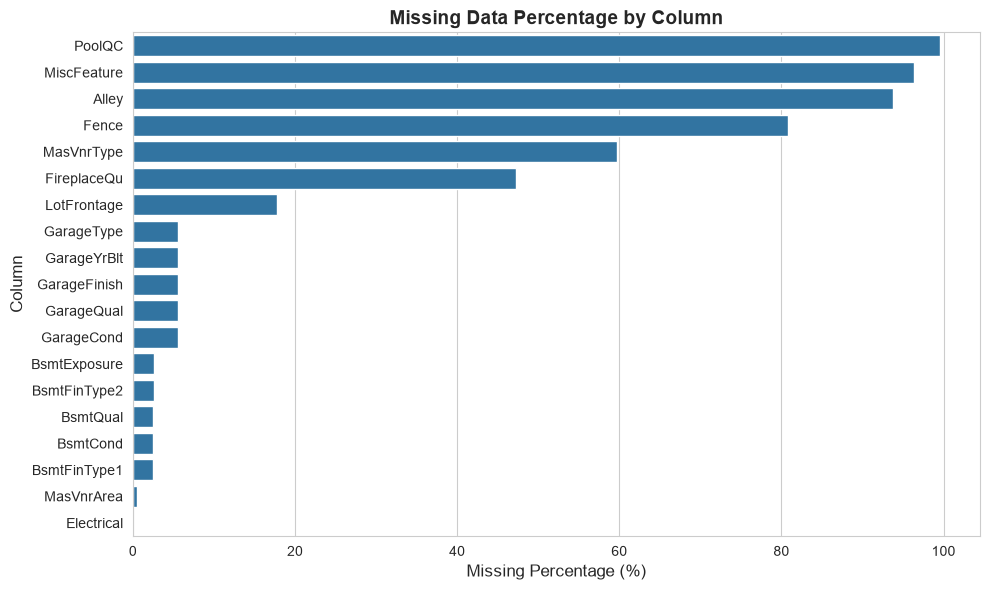

In [14]:

# ---------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_summary["Missing_Percentage"],
    y=missing_summary["Column"],
    
)

plt.xlabel("Missing Percentage (%)", fontsize=12)
plt.ylabel("Column", fontsize=12)
plt.title(
    "Missing Data Percentage by Column", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()


### Treatment Strategies for Each Type but not strict rule must do data analysis
- Strategy 1: Fill with "None" (Categorical, Structural)
- Strategy 2: Fill with 0 (Numerical, Structural)
####  Random
- Fill with Median (Numerical, Random)
 - Fill with Mode (Categorical, Random)

#### (Systematic)
 - Create Missing Indicator Flag 
 - Drop Column (>80% Missing, Not Structural)

## 1. PoolQC (Pool Quality)
- Column Type: Ordinal Categorical
Values: Ex > Gd > TA > Fa > NA (No Pool)
Order: Excellent > Good > Average > Fair > No Pool
- *Missing Value Type:* STRUCTURAL
- *Domain Justification* (data_description.txt):
- *Explicitly states:* "NA = No Pool"
Pool quality only exists if house HAS a pool
Missing = feature doesn't exist, not unknown
Amount of Missing: 1,453 out of 1,460 (99.52%)
Comparison: Missing vs Not Missing


<Axes: xlabel='SalePrice', ylabel='Density'>

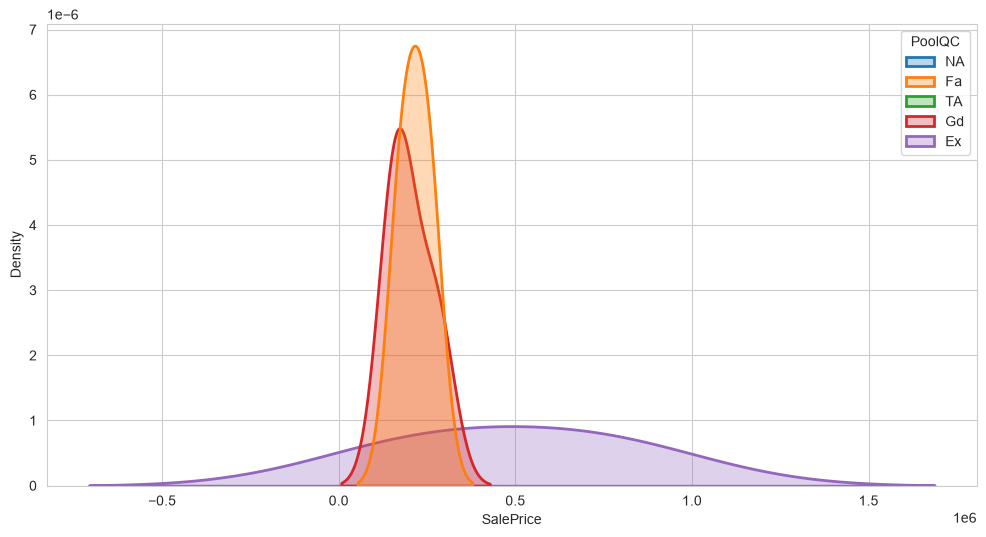

In [15]:
plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=train,
    x='SalePrice',
    hue='PoolQC',
    common_norm=False,      # Scales each curve independently
    fill=True,              # Fills under the curve for the continuous wave look
    alpha=0.3,              # Transparency
    linewidth=2,
    hue_order=['NA', 'Fa', 'TA', 'Gd', 'Ex'] # Forces NA to appear in the legend and plot
)

In [16]:

print(f"Missing (no pool): ${train.loc[train['PoolQC'].isna(), 'SalePrice'].mean():,.0f} | Present (has pool): ${train.loc[train['PoolQC'].notna(), 'SalePrice'].mean():,.0f} | Difference: +${train.loc[train['PoolQC'].notna(), 'SalePrice'].mean() - train.loc[train['PoolQC'].isna(), 'SalePrice'].mean():,.0f} (+{((train.loc[train['PoolQC'].notna(), 'SalePrice'].mean() - train.loc[train['PoolQC'].isna(), 'SalePrice'].mean()) / train.loc[train['PoolQC'].isna(), 'SalePrice'].mean() * 100):.0f}%)")

Missing (no pool): $180,405 | Present (has pool): $288,139 | Difference: +$107,734 (+60%)


<Axes: xlabel='PoolQC', ylabel='SalePrice'>

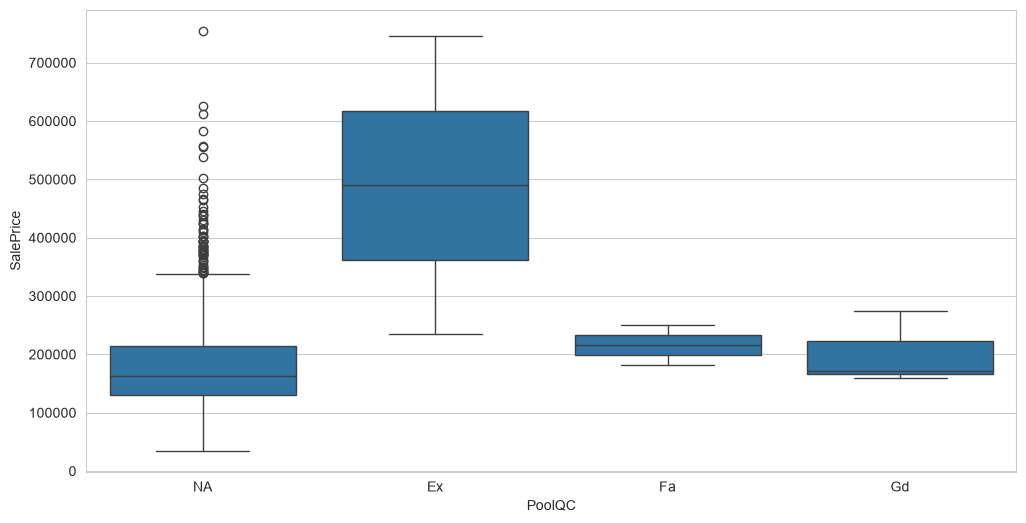

In [17]:
PQ=train['PoolQC']
PQ = PQ.fillna('NA') 
plt.figure(figsize=(12, 6))

sns.boxplot(data=train,x=PQ,y='SalePrice',
             hue_order=['Ex','Fa','Gd','NA'])

## 2. MiscFeature (Miscellaneous Feature)
- Column Type: Nominal Categorical

- Values: Elev, Gar2, Othr, Shed, TenC, NA
No order (just different types)
- Missing Value Type: ** STRUCTURAL

- Domain Justification (data_description.txt):

Explicitly states: "NA = None"
- Miscellaneous features are ADDITIONS (elevator, 2nd garage, tennis court, shed)
Most houses don't have these extras
- Missing = no misc feature exists
Amount of Missing: 1,406 out of 1,460 (96.30%)



In [18]:
print(f"Missing (no misc): ${train.loc[train['MiscFeature'].isna(), 'SalePrice'].mean():,.0f} | Present (has misc): ${train.loc[train['MiscFeature'].notna(), 'SalePrice'].mean():,.0f} | Difference: +${train.loc[train['MiscFeature'].notna(), 'SalePrice'].mean() - train.loc[train['MiscFeature'].isna(), 'SalePrice'].mean():,.0f} (+{((train.loc[train['MiscFeature'].notna(), 'SalePrice'].mean() - train.loc[train['MiscFeature'].isna(), 'SalePrice'].mean()) / train.loc[train['MiscFeature'].isna(), 'SalePrice'].mean() * 100):.0f}%)")

Missing (no misc): $182,046 | Present (has misc): $151,624 | Difference: +$-30,422 (+-17%)


In [19]:
# MC=train['MiscFeature']
# MC = MC.fillna('NA') 
# plt.figure(figsize=(12, 6))

# sns.kdeplot(
#     data=train,
#     x='SalePrice',
#     hue=MC,
#     common_norm=False,      # Scales each curve independently
#                  # Fills under the curve for the continuous wave look
#     alpha=1,              # Transparency
#     linewidth=2,
#     hue_order=[ 'Elev' ,'Gar2','Othr','Shed','TenC','NA']
#     # Forces NA to appear in the legend and plot
# )

### 3. Alley (Alley Access)
- Column Type: Nominal Categorical

- Values: Grvl, Pave, NA
No order (Gravel vs Paved are just different types)
- Missing Value Type: STRUCTURAL

- Domain Justification (data_description.txt):

Explicitly states: "NA = No alley access"
Alley access is special feature (not all properties have it)
Missing = no alley exists
Amount of Missing: 1,369 out of 1,460 (93.77%)



In [20]:
print(f"Missing (no alley): ${train.loc[train['Alley'].isna(), 'SalePrice'].mean():,.0f} | Present (has alley): ${train.loc[train['Alley'].notna(), 'SalePrice'].mean():,.0f} | Difference: +${train.loc[train['Alley'].notna(), 'SalePrice'].mean() - train.loc[train['Alley'].isna(), 'SalePrice'].mean():,.0f} (+{((train.loc[train['Alley'].notna(), 'SalePrice'].mean() - train.loc[train['Alley'].isna(), 'SalePrice'].mean()) / train.loc[train['Alley'].isna(), 'SalePrice'].mean() * 100):.0f}%)")

Missing (no alley): $183,452 | Present (has alley): $142,846 | Difference: +$-40,606 (+-22%)


Fence (Fence Quality)
Column Type: Ordinal Categorical

Values: GdPrv > MnPrv > GdWo > MnWw > NA
Order: Good Privacy > Min Privacy > Good Wood > Min Wood > No Fence
Missing Value Type: STRUCTURAL

Domain Justification (data_description.txt):

Explicitly states: "NA = No Fence"
Fence quality only exists if house HAS a fence
Missing = no fence exists
Amount of Missing: 1,179 out of 1,460 (80.75%)



In [21]:

print(f"Missing (no fence): ${train.loc[train['Fence'].isna(), 'SalePrice'].mean():,.0f} | Present (has fence): ${train.loc[train['Fence'].notna(), 'SalePrice'].mean():,.0f} | Difference: +${train.loc[train['Fence'].notna(), 'SalePrice'].mean() - train.loc[train['Fence'].isna(), 'SalePrice'].mean():,.0f} (+{((train.loc[train['Fence'].notna(), 'SalePrice'].mean() - train.loc[train['Fence'].isna(), 'SalePrice'].mean()) / train.loc[train['Fence'].isna(), 'SalePrice'].mean() * 100):.0f}%)")

Missing (no fence): $187,597 | Present (has fence): $152,912 | Difference: +$-34,685 (+-18%)


 ### LotFrontage (Linear Feet of Street Connected)
Column Type: Numerical Continuous

Values: Decimal allowed (e.g., 65.5, 80.0)
Physical measurement
Missing Value Type: RANDOM (MCAR)

Domain Justification (data_description.txt):

No "NA = ..." statement
ALL lots have street frontage (physical necessity)
Missing = data collection issue (not recorded, lost, not entered)
No pattern to missingness
Amount of Missing: 259 out of 1,460 (17.74%)

MISSING (259 houses):
→ Lot HAS frontage (all lots do)
→ Value just not recorded
→ Random data collection issue

In [22]:
print(f"Missing (unknown): ${train.loc[train['LotFrontage'].isna(), 'SalePrice'].mean():,.0f} | Present (recorded): ${train.loc[train['LotFrontage'].notna(), 'SalePrice'].mean():,.0f} | Difference: +${train.loc[train['LotFrontage'].notna(), 'SalePrice'].mean() - train.loc[train['LotFrontage'].isna(), 'SalePrice'].mean():,.0f} (+{((train.loc[train['LotFrontage'].notna(), 'SalePrice'].mean() - train.loc[train['LotFrontage'].isna(), 'SalePrice'].mean()) / train.loc[train['LotFrontage'].isna(), 'SalePrice'].mean() * 100):.0f}%)")

Missing (unknown): $181,620 | Present (recorded): $180,770 | Difference: +$-850 (+-0%)


# CELL 5: EDA - CORRELATION ANALYSIS

In [23]:
# 1. Numeric Correlation
numeric_cols = train.select_dtypes(include=[np.number]).columns
numeric_corr = train[numeric_cols].corr()['SalePrice'].abs().sort_values(ascending=False)

# 2. Categorical Importance (ANOVA F-test)
cat_cols = train.select_dtypes(include=['object']).columns
# We fill NA with 'None' so the encoder can process it
cat_data = train[cat_cols].fillna('None')

# Convert categories to numbers so we can run the test
encoded_cat = cat_data.apply(LabelEncoder().fit_transform)
f_scores, _ = f_regression(encoded_cat, train['SalePrice'])
cat_importance = pd.Series(f_scores, index=cat_cols).sort_values(ascending=False)

# 3. Combine and print
print("--- TOP 10 NUMERIC ---")
print(numeric_corr.head(10))
print("\n--- TOP 10 CATEGORICAL ---")
print(cat_importance.head(10))

--- TOP 10 NUMERIC ---
SalePrice        1.000000
SalePrice_Log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
Name: SalePrice, dtype: float64

--- TOP 10 CATEGORICAL ---
ExterQual       994.979678
BsmtQual        793.806890
KitchenQual     775.262307
GarageFinish    322.670023
GarageType      303.848427
HeatingQC       278.007890
Foundation      249.840256
BsmtExposure    153.953618
LotShape        101.893942
CentralAir       98.305344
dtype: float64


BsmtQual        793.806890
GarageFinish    322.670023
GarageType      303.848427
BsmtExposure    153.953618

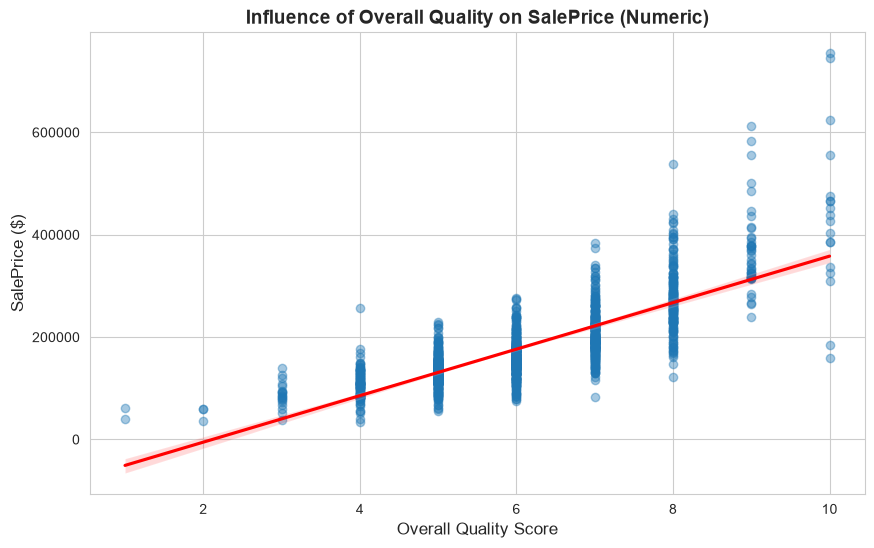

In [24]:
plt.figure(figsize=(10, 6))
# Visualizing our #1 numeric feature: OverallQual
sns.regplot(
    data=train, 
    x='OverallQual', 
    y='SalePrice',
    scatter_kws={'alpha': 0.4}, 
    line_kws={'color': 'red'}
)
plt.title('Influence of Overall Quality on SalePrice (Numeric)', fontsize=14, fontweight='bold')
plt.xlabel('Overall Quality Score', fontsize=12)
plt.ylabel('SalePrice ($)', fontsize=12)
plt.show()

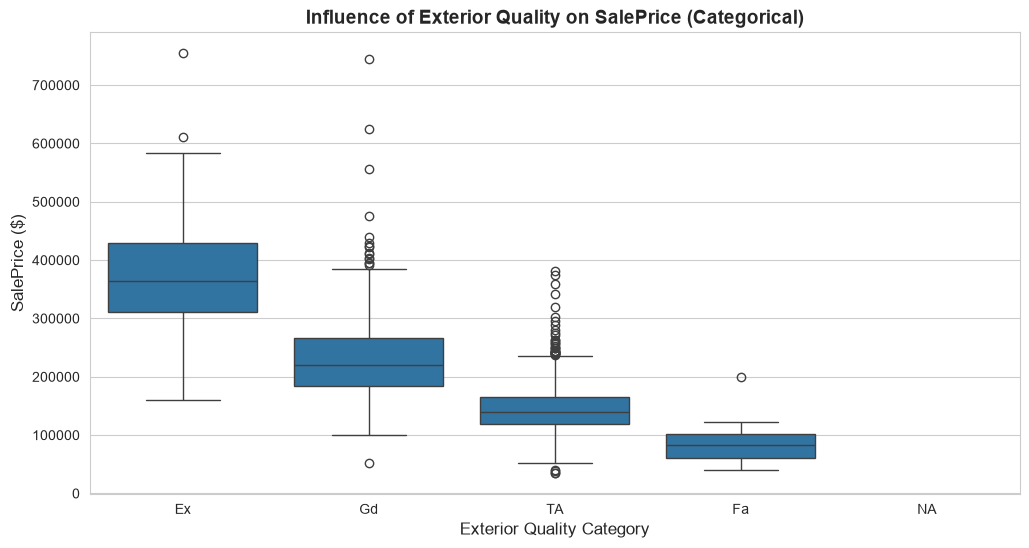

In [25]:
plt.figure(figsize=(12, 6))
PQ=train['ExterQual']
PQ = PQ.fillna('NA') 
# Visualizing our #1 categorical feature: ExterQual
sns.boxplot(
    data=train, 
    x=PQ, 
    y='SalePrice',
    order=['Ex', 'Gd', 'TA', 'Fa','NA'] # Ordering from best to worst quality
)
plt.title('Influence of Exterior Quality on SalePrice (Categorical)', fontsize=14, fontweight='bold')
plt.xlabel('Exterior Quality Category', fontsize=12)
plt.ylabel('SalePrice ($)', fontsize=12)
plt.show()

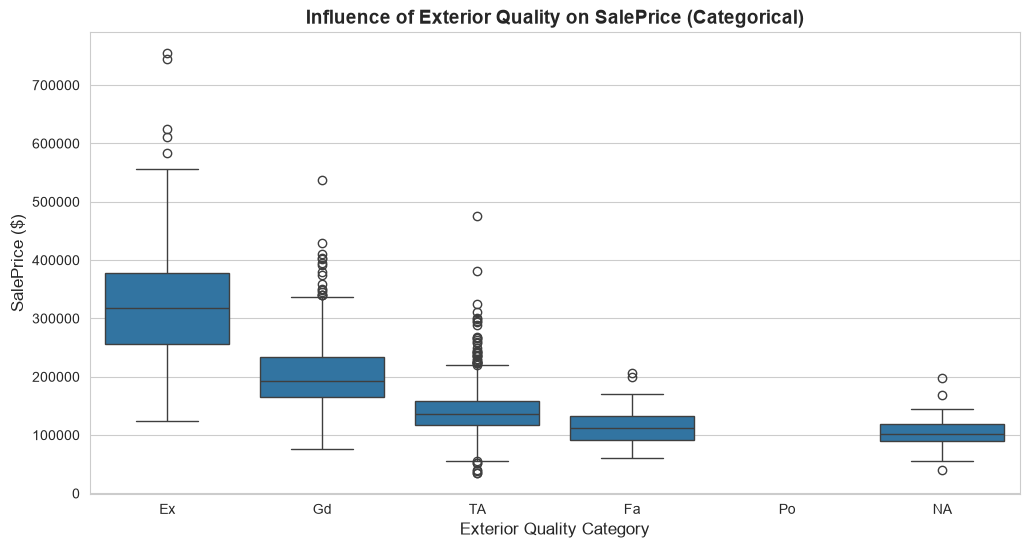

In [26]:
plt.figure(figsize=(12, 6))
PQ=train['BsmtQual']
PQ = PQ.fillna('NA') 
# # Visualizing our #1 categorical feature: ExterQual
# Ex	Excellent (100+ inches)	
#        Gd	Good (90-99 inches)
#        TA	Typical (80-89 inches)
#        Fa	Fair (70-79 inches)
#        Po	Poor (<70 inches
#        NA	No Basement
sns.boxplot(
    data=train, 
    x=PQ, 
    y='SalePrice',
    order=['Ex', 'Gd', 'TA', 'Fa','Po','NA'] # Ordering from best to worst quality
)
plt.title('Influence of Exterior Quality on SalePrice (Categorical)', fontsize=14, fontweight='bold')
plt.xlabel('Exterior Quality Category', fontsize=12)
plt.ylabel('SalePrice ($)', fontsize=12)
plt.show()

## IImplement the treatment for Missing Value in top7.

In [27]:
# =============================================================================
# MISSING VALUE TREATMENT (Top 7 Treated + Remaining Null Table)
# =============================================================================

# 1. Get ALL missing columns and slice out the top 7
all_missing_cols = missing_summary['Column'].tolist()
top_7_missing_cols = all_missing_cols[:7]
remaining_missing_cols = all_missing_cols[7:]

print("Top 7 columns treated:")
print(top_7_missing_cols)
print("-" * 50)

# 2. Separate and treat top 7
cat_missing_top7 = train[top_7_missing_cols].select_dtypes(include=['object', 'category']).columns
num_missing_top7 = train[top_7_missing_cols].select_dtypes(include=[np.number]).columns

for col in cat_missing_top7:
    train[col] = train[col].fillna('None')

for col in num_missing_top7:
    train[col] = train[col].fillna(train[col].mean())

# 3. Build a summary table for the remaining columns and their null counts
remaining_null_counts = train[remaining_missing_cols].isnull().sum()
remaining_table = pd.DataFrame({
    'Column Name': remaining_null_counts.index,
    'Remaining Null Count': remaining_null_counts.values
})

# Filter to keep only columns that actually have nulls left
remaining_table = remaining_table[remaining_table['Remaining Null Count'] > 0].reset_index(drop=True)

print("=" * 80)
print("TOP 7 MISSING VALUES HANDLED")
print("=" * 80)
print(f"Remaining null count in top 7: {train[top_7_missing_cols].isnull().sum().sum()}")
print("\n📊 TABLE OF REMAINING COLUMNS WITH NULL VALUES:")
print("-" * 80)
print(remaining_table.to_string(index=False))

Top 7 columns treated:
['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'LotFrontage']
--------------------------------------------------
TOP 7 MISSING VALUES HANDLED
Remaining null count in top 7: 0

📊 TABLE OF REMAINING COLUMNS WITH NULL VALUES:
--------------------------------------------------------------------------------
 Column Name  Remaining Null Count
  GarageType                    81
 GarageYrBlt                    81
GarageFinish                    81
  GarageQual                    81
  GarageCond                    81
BsmtExposure                    38
BsmtFinType2                    38
    BsmtQual                    37
    BsmtCond                    37
BsmtFinType1                    37
  MasVnrArea                     8
  Electrical                     1


# Phase 3 (Univariate EDA)

In [28]:
# 1. Extract Top Features Dynamically
top_10_numeric = numeric_corr.head(10).index.tolist()
top_10_numeric = [col for col in top_10_numeric if col != 'SalePrice']
top_10_categorical = cat_importance.head(10).index.tolist()

### STEP 1: Numerical Features — Histograms, Boxplots & Skewness Check

- Skew = 0: Perfectly symmetrical (like a normal bell curve).
- Skew between -0.5 and +0.5: Fairly symmetrical, normal-looking data.
- Skew between -0.75 and -0.5 (or +0.5 and +0.75): Moderately skewed.
- Skew > 0.75 or < -0.75 (Our Rule): Notably skewed.

If the number is positive (e.g., $+1.5$), it has a right-skew (a long tail stretching to the right, meaning a few houses have massive values like huge living areas).If the number is negative (e.g., $-1.5$), it has a left-skew (a long tail stretching to the left, meaning a few houses have unusually low values).

📈 STEP 1: NUMERICAL DISTRIBUTIONS & SKEWNESS TABLE


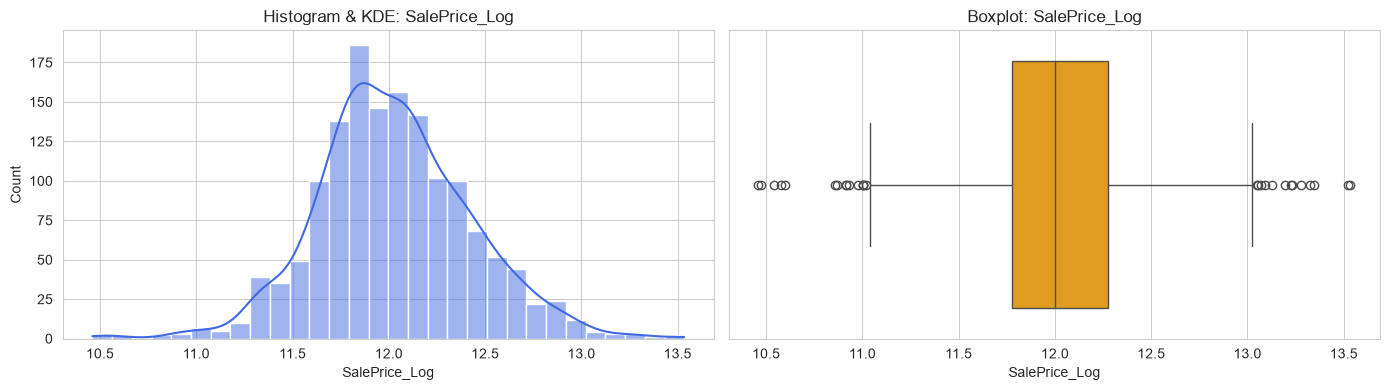

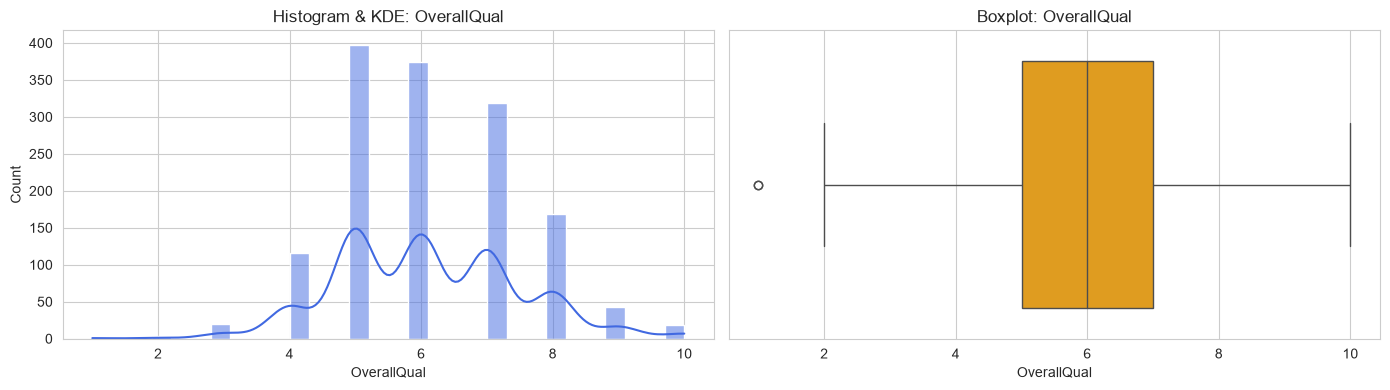

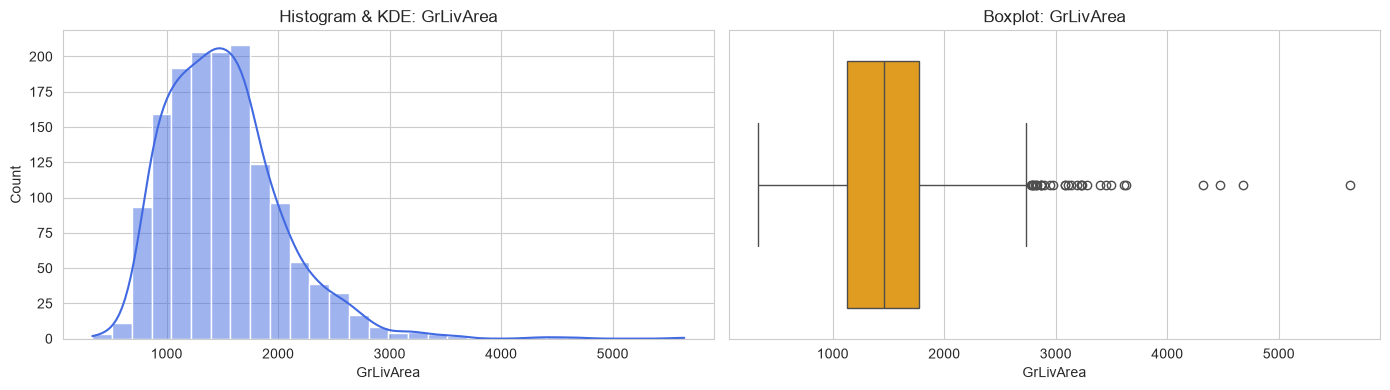

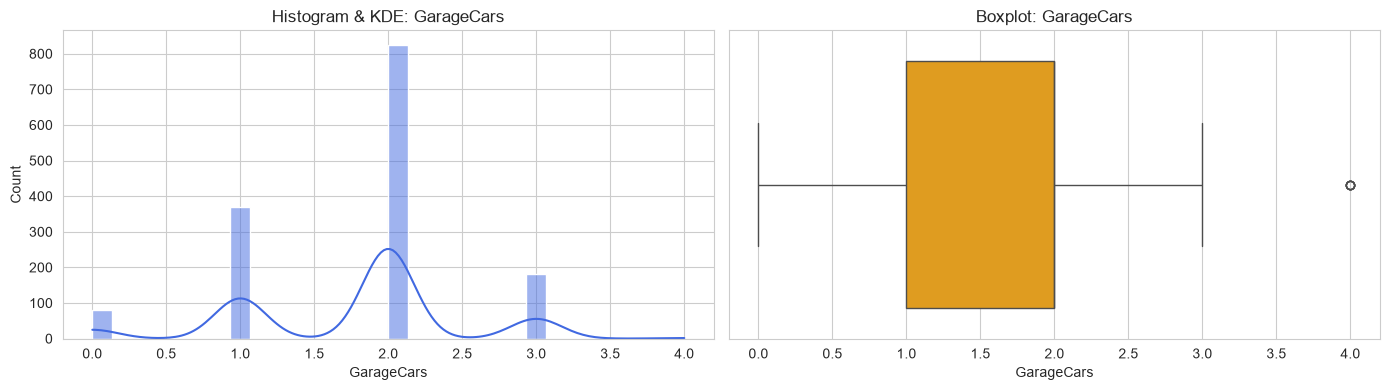

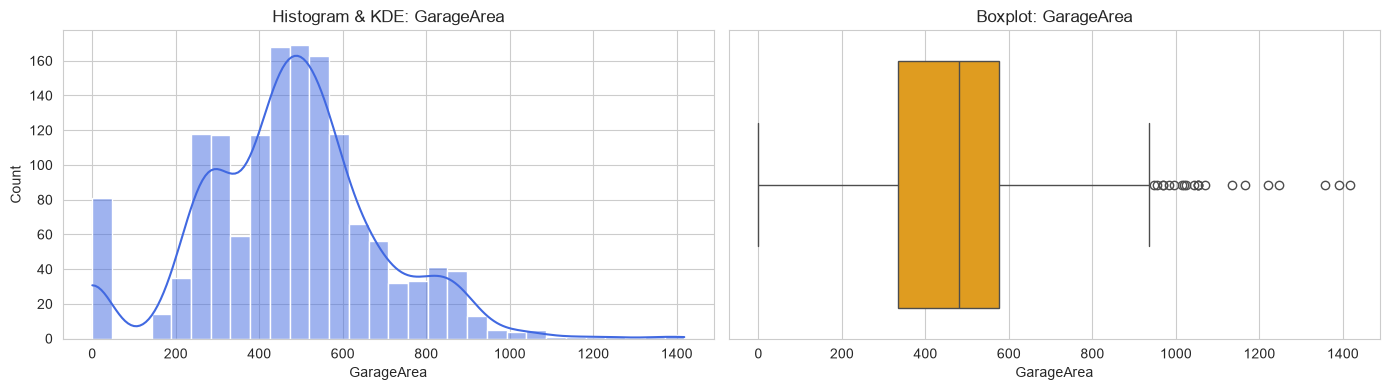

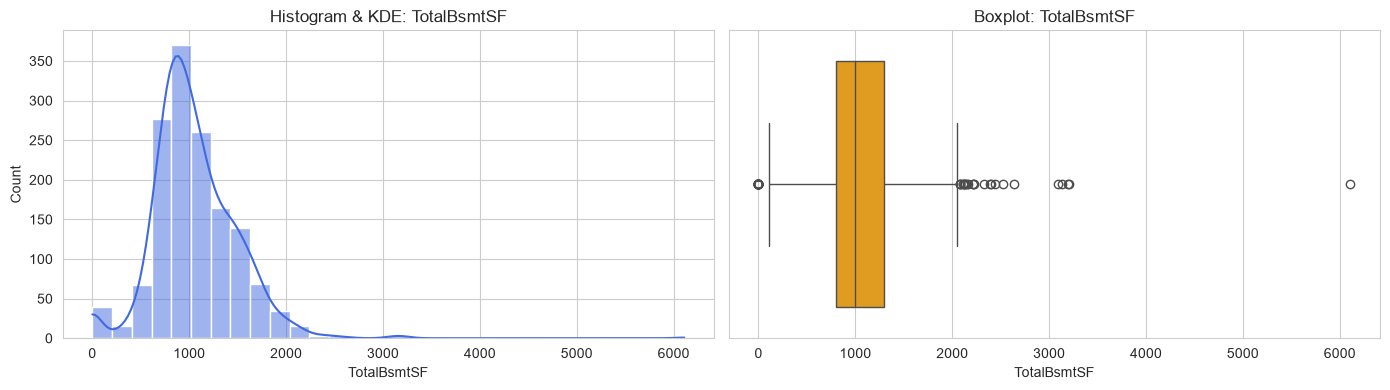

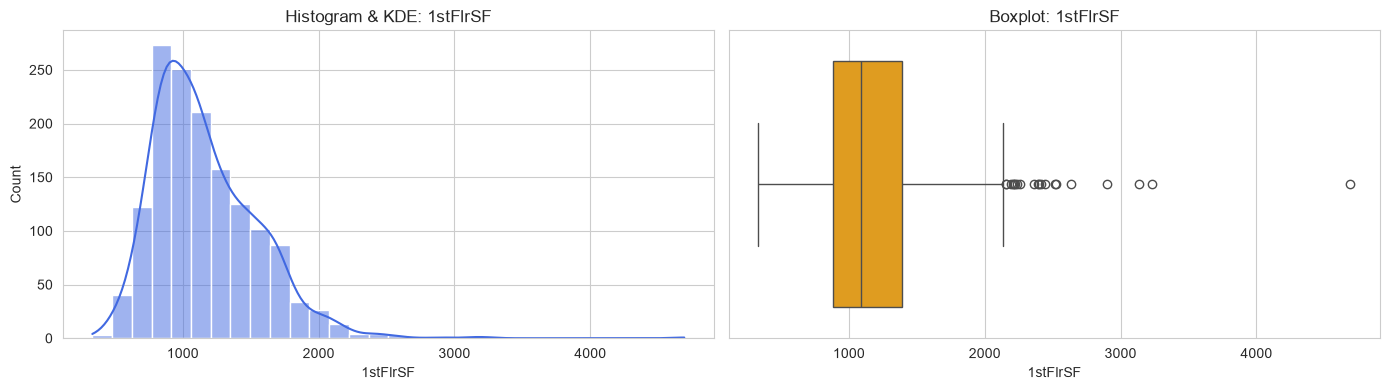

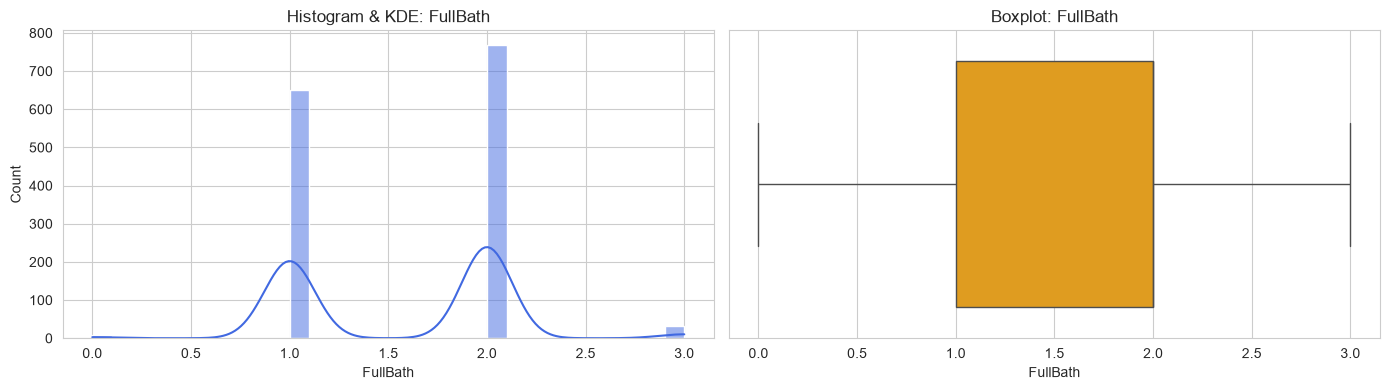

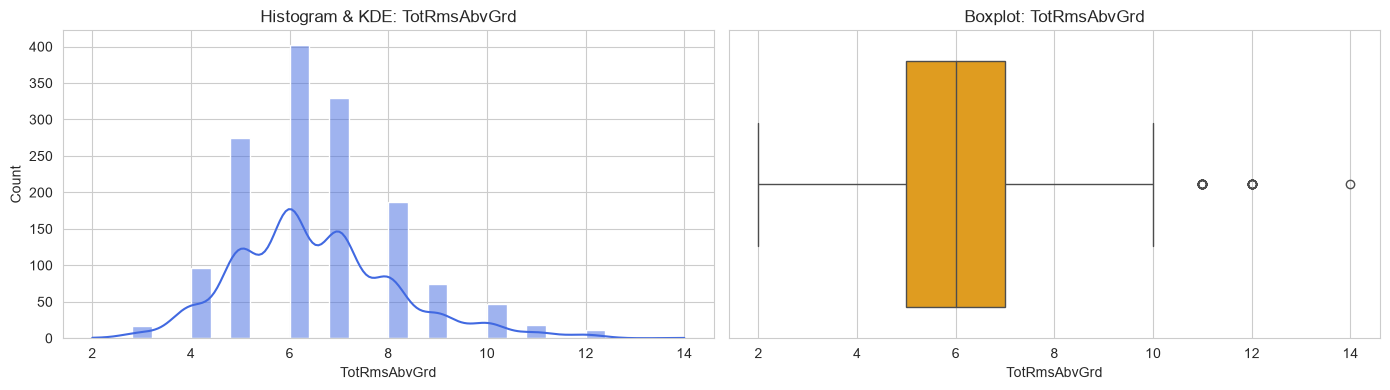


📊 SKEWNESS & KURTOSIS SUMMARY TABLE:
--------------------------------------------------
      Feature  Skewness  Kurtosis
SalePrice_Log  0.121222  0.802643
  OverallQual  0.216721  0.091857
    GrLivArea  1.365156  4.874266
   GarageCars -0.342197  0.216135
   GarageArea  0.179796  0.909823
  TotalBsmtSF  1.522688 13.201042
     1stFlrSF  1.375342  5.722076
     FullBath  0.036524 -0.858217
 TotRmsAbvGrd  0.675646  0.873641

Notably Skewed Top Numeric Features (|Skew| > 0.75): ['GrLivArea', 'TotalBsmtSF', '1stFlrSF']


In [29]:
print("=" * 80)
print("📈 STEP 1: NUMERICAL DISTRIBUTIONS & SKEWNESS TABLE")
print("=" * 80)

skew_results = []
skewed_top_numeric = []

for col in top_10_numeric:
    col_skew = skew(train[col])
    col_kurt = kurtosis(train[col])
    
    skew_results.append({
        'Feature': col,
        'Skewness': col_skew,
        'Kurtosis': col_kurt
    })
    
    if abs(col_skew) > 0.75:
        skewed_top_numeric.append(col)
        
    # Visualizations: Histogram + KDE & Boxplot for each continuous numeric feature
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    sns.histplot(train[col], kde=True, ax=axes[0], color="royalblue", bins=30)
    axes[0].set_title(f"Histogram & KDE: {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")
    
    sns.boxplot(x=train[col], ax=axes[1], color="orange")
    axes[1].set_title(f"Boxplot: {col}")
    axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

# Print results as a clean DataFrame table
skew_table = pd.DataFrame(skew_results)
print("\n📊 SKEWNESS & KURTOSIS SUMMARY TABLE:")
print("-" * 50)
print(skew_table.to_string(index=False))
print(f"\nNotably Skewed Top Numeric Features (|Skew| > 0.75): {skewed_top_numeric}")

## STEP 2: Categorical Features — Value Count Bar Plots & Rare Categories (< 1%)


📊 STEP 2: CATEGORICAL VALUE COUNTS & RARE CATEGORY CHECK

Feature [ExterQual] has rare categories (< 1%):
   - Category 'Fa': 0.96%


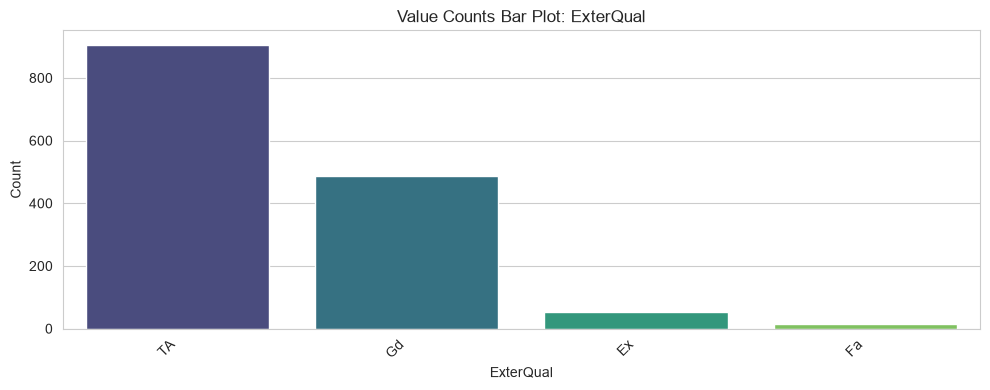


Feature [BsmtQual]: No rare categories under 1%.


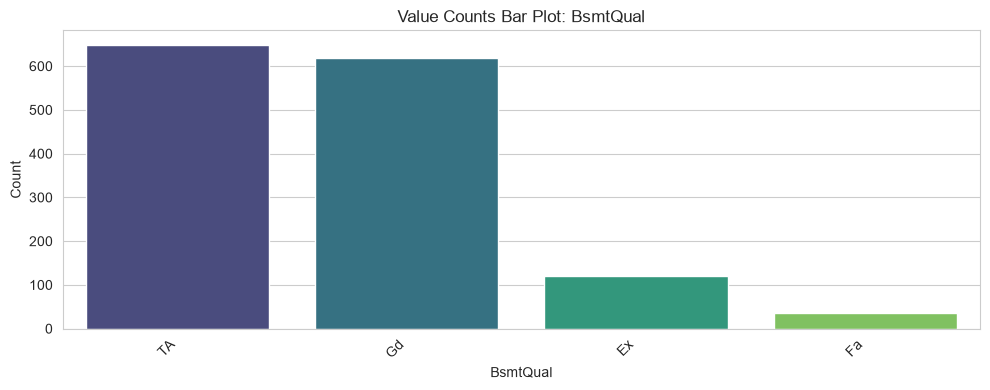


Feature [KitchenQual]: No rare categories under 1%.


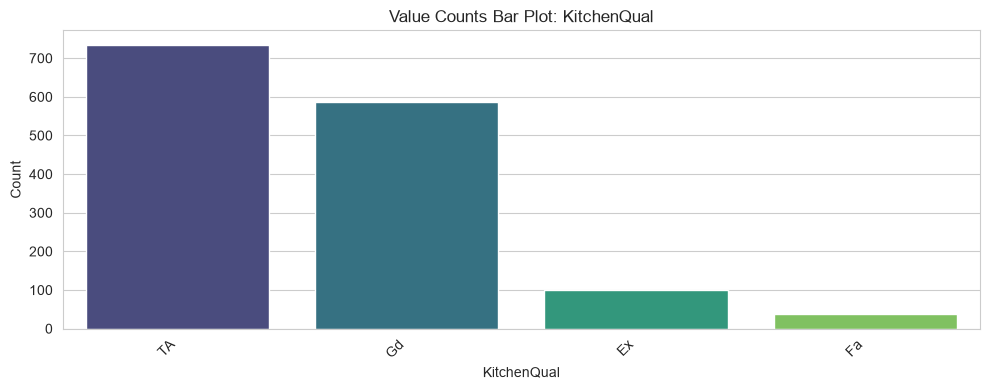


Feature [GarageFinish]: No rare categories under 1%.


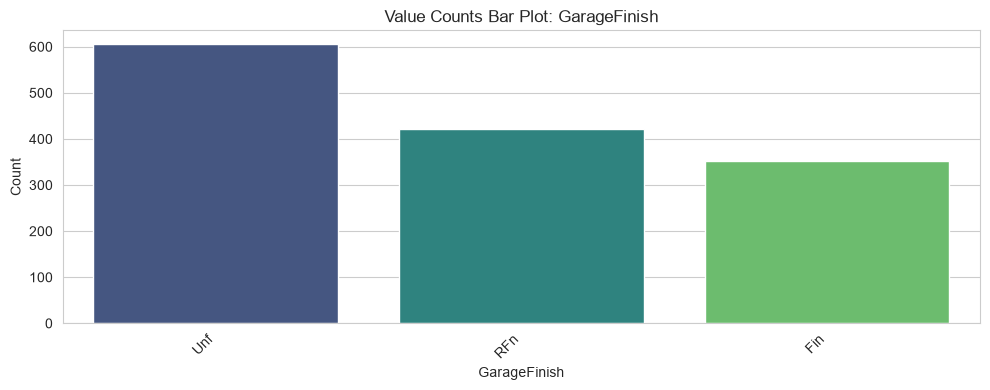


Feature [GarageType] has rare categories (< 1%):
   - Category 'CarPort': 0.65%
   - Category '2Types': 0.44%


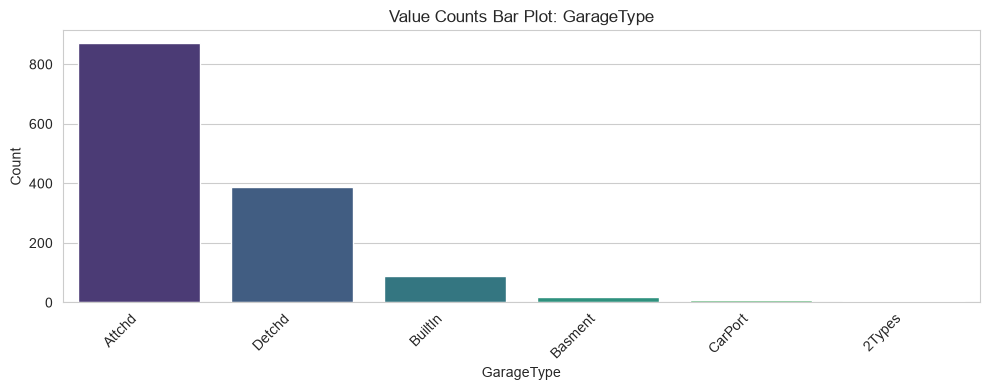


Feature [HeatingQC] has rare categories (< 1%):
   - Category 'Po': 0.07%


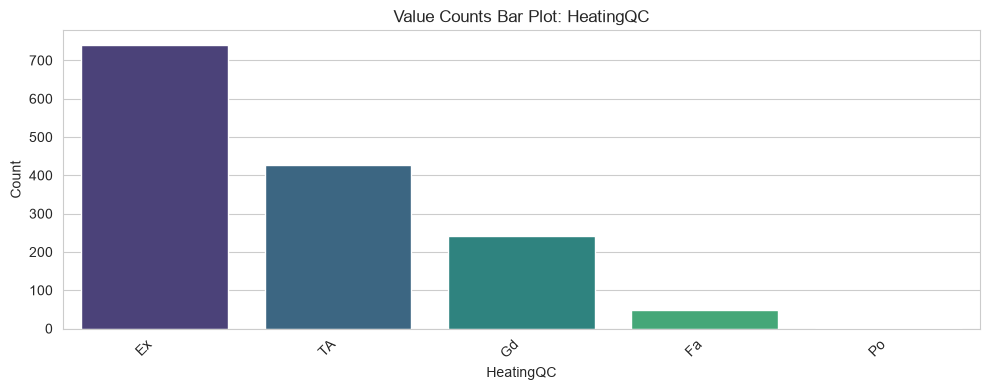


Feature [Foundation] has rare categories (< 1%):
   - Category 'Stone': 0.41%
   - Category 'Wood': 0.21%


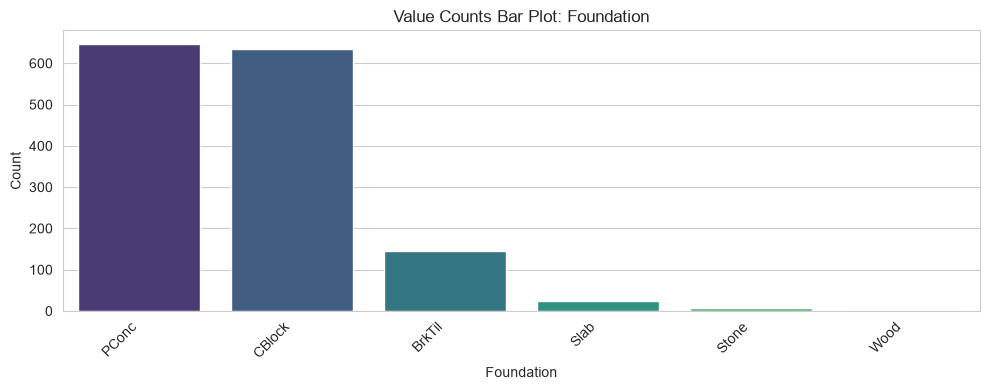


Feature [BsmtExposure]: No rare categories under 1%.


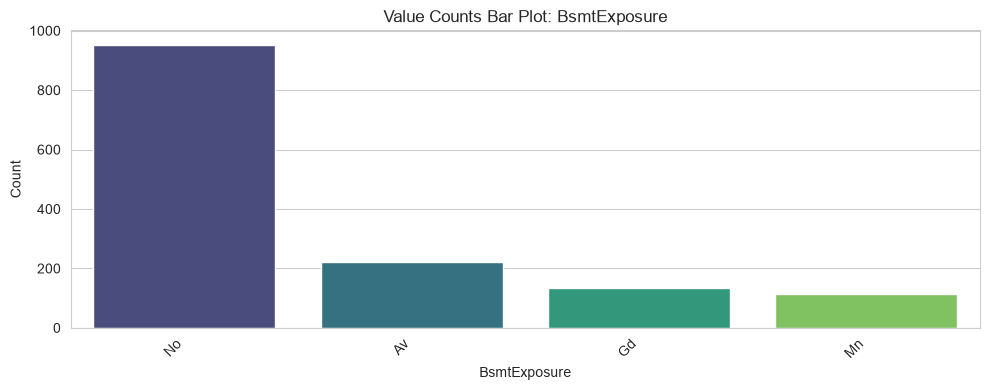


Feature [LotShape] has rare categories (< 1%):
   - Category 'IR3': 0.68%


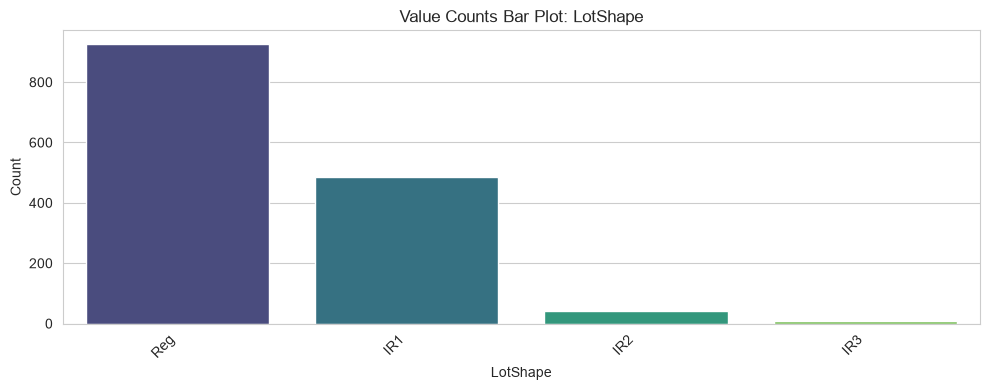


Feature [CentralAir]: No rare categories under 1%.


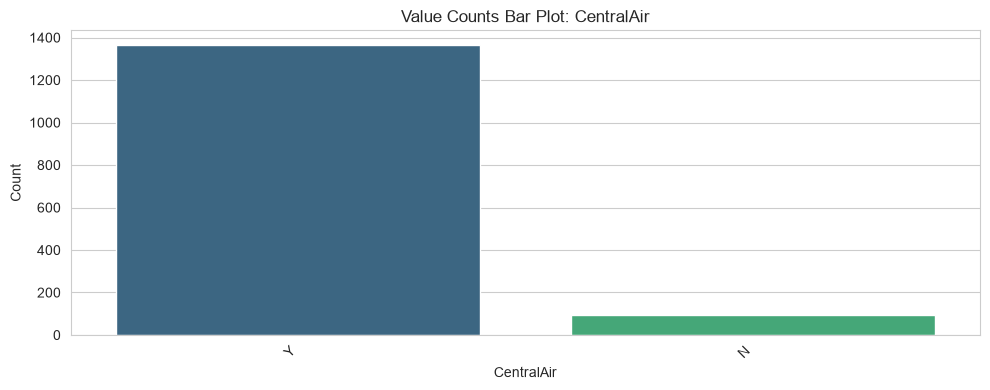

In [30]:

# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("📊 STEP 2: CATEGORICAL VALUE COUNTS & RARE CATEGORY CHECK")
print("=" * 80)

for col in top_10_categorical:
    val_counts = train[col].value_counts(normalize=True) * 100
    rare_cats = val_counts[val_counts < 1.0]
    
    if not rare_cats.empty:
        print(f"\nFeature [{col}] has rare categories (< 1%):")
        for cat, pct in rare_cats.items():
            print(f"   - Category '{cat}': {pct:.2f}%")
    else:
        print(f"\nFeature [{col}]: No rare categories under 1%.")
        
    # Visualization: Bar plot of value counts for categorical features
    plt.figure(figsize=(10, 4))
    sns.countplot(data=train, x=col, order=train[col].value_counts().index, palette="viridis")
    plt.title(f"Value Counts Bar Plot: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Outlier
values that are unusuak for given context
we can find outlier but it is difficult to understand what to do with them.

Solition:
- Trimming: Trim the outlier but it has disadvantage that if a feature have too many outlier it mean many of datapoint will be get loss and data become thin .but this approach is fast
- capping:  set upper and lower limit and remove point outside of it
- treat it like missing value



### how to Detect Outlier
 
 - Normal Distribution
  u=mean
  if any datapoint is outside of  mean+3SD or mean-3SD  we treat them as outlier

  - Skewed Distriibution:
   use interquartile : plot boxpolt
   Q1,Q3= quantile
    min=Q1-1.5IQR
    max=Q3+1.5IQR
    are  outside them are outlier

  - other Distribution:
        percentile approach:
      2.5 percentile 
      97.5 percentile

### Removal technique

    - Z-score
            mean=u
            feature 68% value ={ u+SD,u-SD},
                     95%value ={ u+2SD,u-2SD},
                    99.7% value ={u+3*SD,u-3*SD}
            removal:
            - trimming : remove rows
            - capping:  outlier value are change to uper and lower limit


    - IQR board filtering
    - percentile






 IQR OUTLIER DETECTION & SALEPRICE CROSS-CHECK ON KEY CONTINUOUS FEATURES

🔍 IQR OUTLIER DETECTION & SALEPRICE CROSS-CHECK (5 Continuous Features)

Feature [SalePrice_Log]: Found 28 statistical outliers beyond 1.5x IQR.
   - Lower Bound: 11.03 | Upper Bound: 13.02


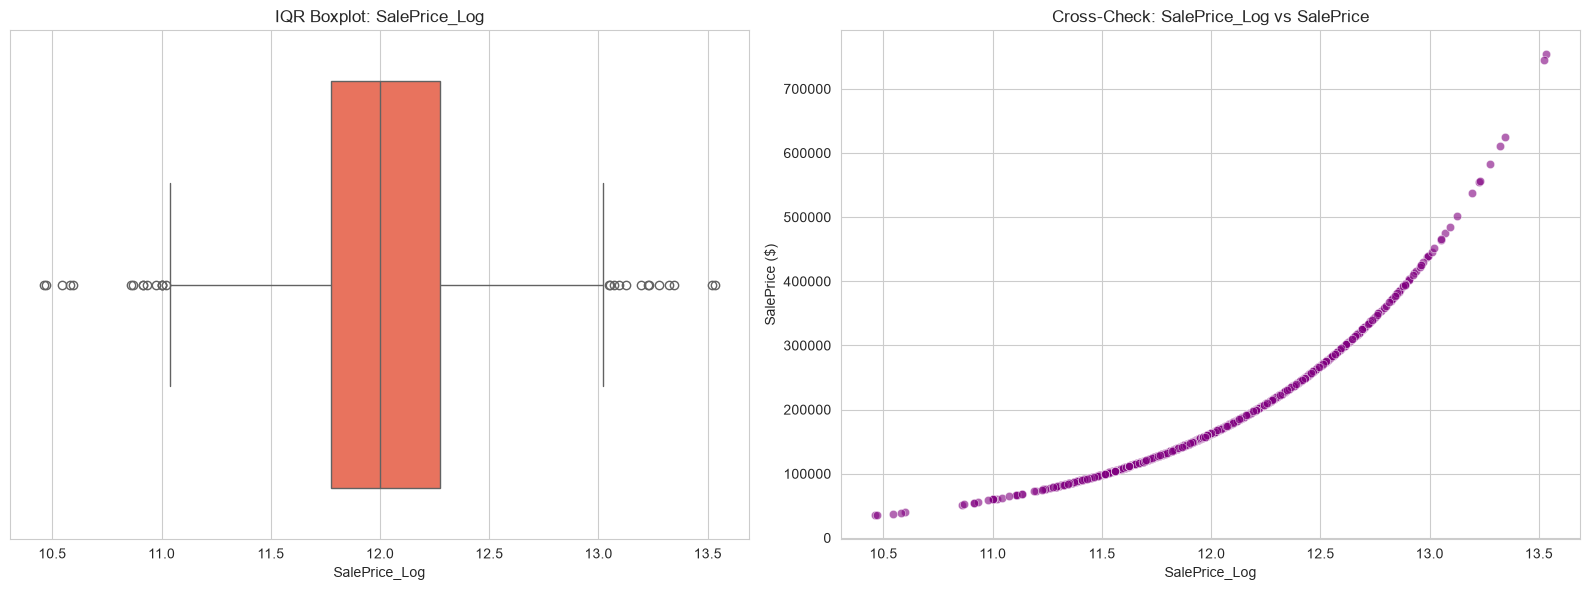


Feature [GrLivArea]: Found 31 statistical outliers beyond 1.5x IQR.
   - Lower Bound: 158.62 | Upper Bound: 2747.62


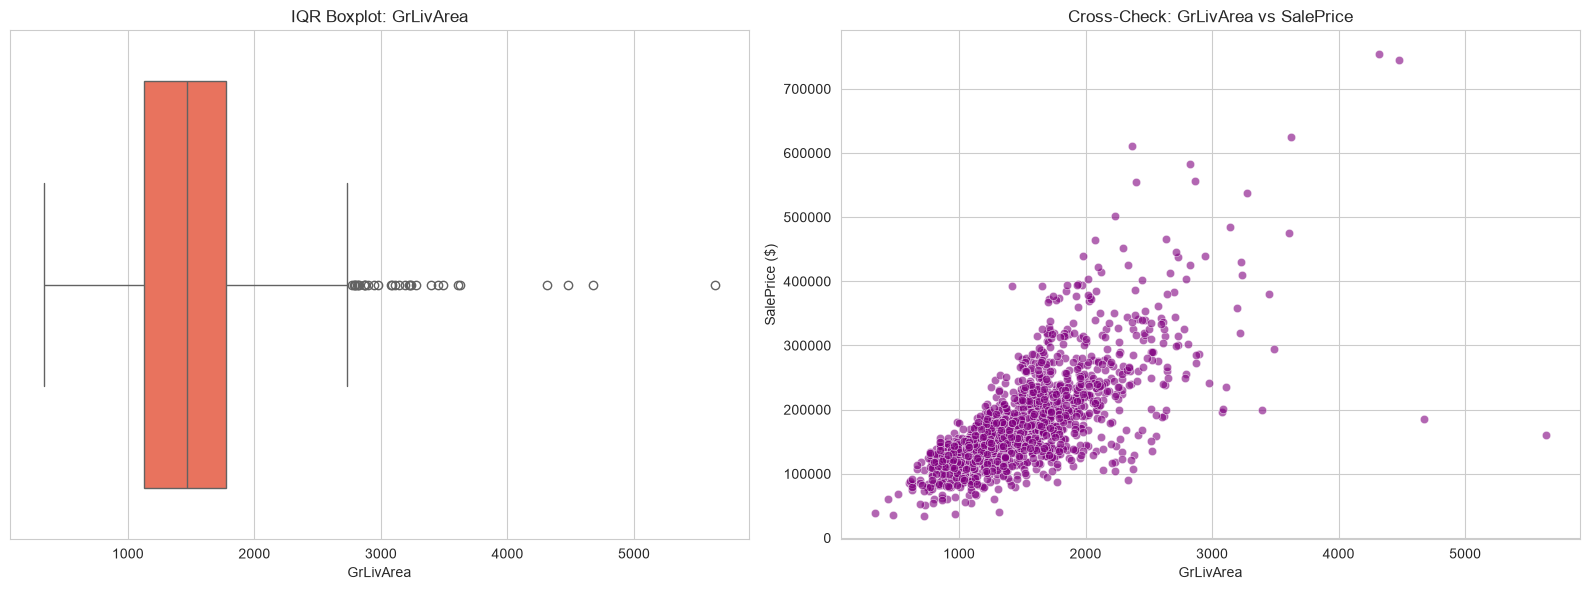


Feature [GarageArea]: Found 21 statistical outliers beyond 1.5x IQR.
   - Lower Bound: 0.00 | Upper Bound: 938.25


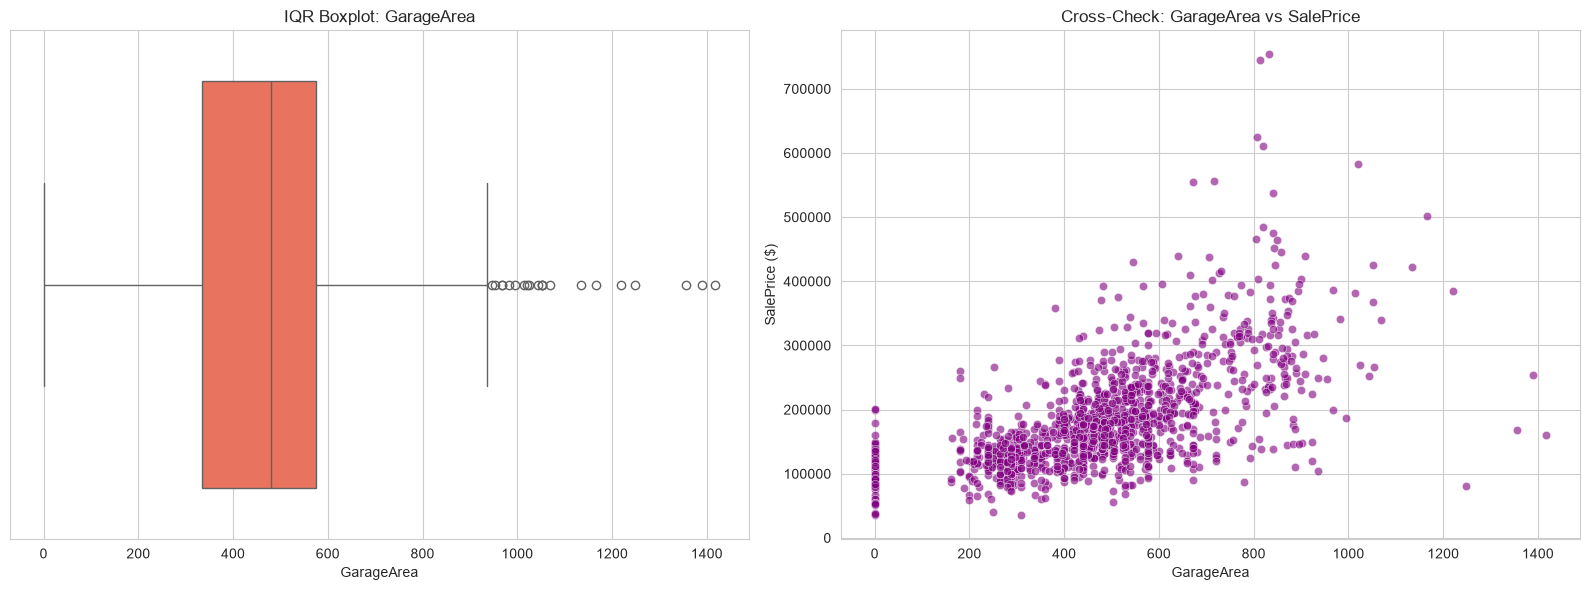


Feature [TotalBsmtSF]: Found 61 statistical outliers beyond 1.5x IQR.
   - Lower Bound: 42.00 | Upper Bound: 2052.00


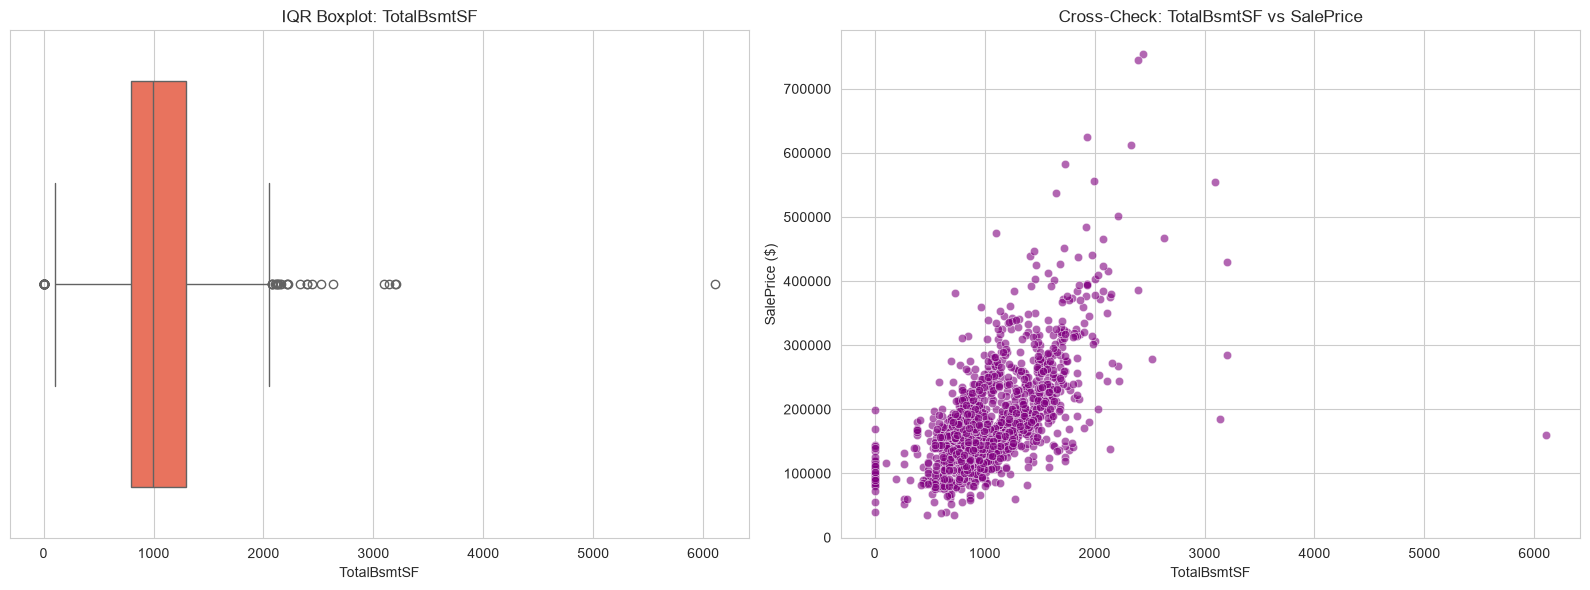


Feature [1stFlrSF]: Found 20 statistical outliers beyond 1.5x IQR.
   - Lower Bound: 118.12 | Upper Bound: 2155.12


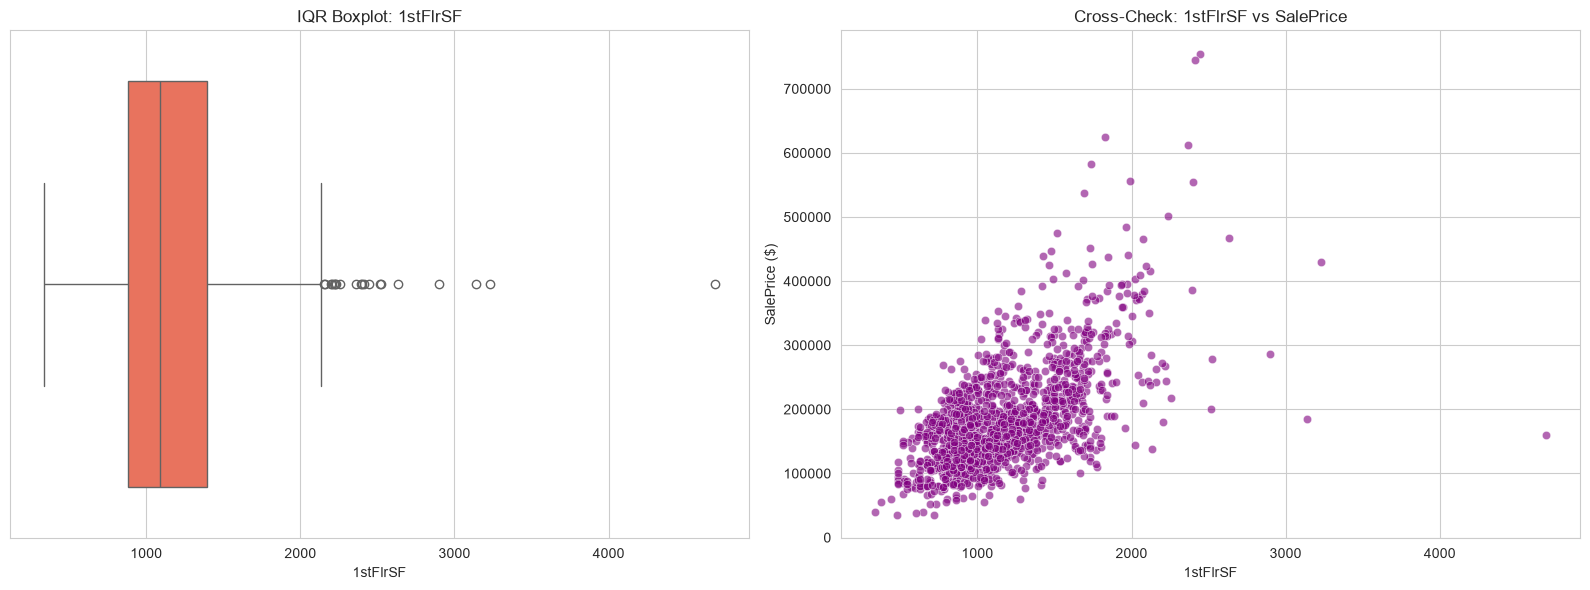

In [31]:
# =============================================================================
# IQR OUTLIER DETECTION & SALEPRICE CROSS-CHECK (DYNAMIC CONTINUOUS FILTER)
# =============================================================================

# Exclude 'SalePrice' and dynamically filter out discrete/ordinal features 
# (e.g., features with very few unique integer values like OverallQual, GarageCars, FullBath)
outlier_check_cols = [
    col for col in top_10_numeric 
    if col != 'SalePrice' 
    and col in train.columns 
    and train[col].nunique() > 15  # Continuous features have many unique values; discrete features have few.
]

print("=" * 80)
print(f"🔍 IQR OUTLIER DETECTION & SALEPRICE CROSS-CHECK ({len(outlier_check_cols)} Continuous Features)")
print("=" * 80)

for col in outlier_check_cols:
    # 1. Calculate Q1, Q3, and IQR
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # 2. Set statistical fences (1.5x IQR) with a physical floor of 0
    lower_bound = max(0.0, Q1 - 1.5 * IQR)
    upper_bound = Q3 + 1.5 * IQR
    
    # 3. Filter outliers
    outliers = train[(train[col] < lower_bound) | (train[col] > upper_bound)]
    print(f"\nFeature [{col}]: Found {len(outliers)} statistical outliers beyond 1.5x IQR.")
    print(f"   - Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}")
    
    # 4. Visualizations: Boxplot for distribution spread + Scatter plot cross-check against SalePrice
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Boxplot
    sns.boxplot(x=train[col], ax=axes[0], color="tomato")
    axes[0].set_title(f"IQR Boxplot: {col}")
    axes[0].set_xlabel(col)
    
    # Cross-Check Scatter Plot against SalePrice
    sns.scatterplot(data=train, x=col, y='SalePrice', ax=axes[1], color="purple", alpha=0.6)
    axes[1].set_title(f"Cross-Check: {col} vs SalePrice")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("SalePrice ($)")
    
    plt.tight_layout()
    plt.show()

### Outlier Treatment (Apply to Training Data)
WHY: We apply outlier treatment BEFORE splitting into train/test to ensure
consistent data quality. However, we ONLY learn bounds from training data.

In [32]:
train_model = train.copy()

# GrLivArea: remove the extreme point(s) > 4000 (overrides your log's "Keep All")
before = len(train_model)
train_model = train_model[train_model['GrLivArea'] <= 4000].reset_index(drop=True)
print(f"Removed {before - len(train_model)} row(s) where GrLivArea > 4000")

# TotalBsmtSF: the >4000 data-error row is already gone above; cap the rest at 2052
train_model['TotalBsmtSF'] = train_model['TotalBsmtSF'].clip(upper=2052)

# GarageArea: cap at the upper IQR bound from your log
train_model['GarageArea'] = train_model['GarageArea'].clip(upper=938.25)

# GrLivArea (remaining) and 1stFlrSF: your log says KEEP — no change

Removed 4 row(s) where GrLivArea > 4000


In [33]:


# 2. Print every column name, its datatype, and how many unique values it has
col_info = pd.DataFrame({
    'Column_Name': train.columns,
    'Data_Type': train.dtypes.values,
    'Unique_Values': [train[col].nunique() for col in train.columns]
})

# Display columns sorted by data type and unique count
print(col_info.to_string(index=False))

  Column_Name Data_Type  Unique_Values
           Id     int64           1460
   MSSubClass     int64             15
     MSZoning       str              5
  LotFrontage   float64            111
      LotArea     int64           1073
       Street       str              2
        Alley       str              3
     LotShape       str              4
  LandContour       str              4
    Utilities       str              2
    LotConfig       str              5
    LandSlope       str              3
 Neighborhood       str             25
   Condition1       str              9
   Condition2       str              8
     BldgType       str              5
   HouseStyle       str              8
  OverallQual     int64             10
  OverallCond     int64              9
    YearBuilt     int64            112
 YearRemodAdd     int64             61
    RoofStyle       str              6
     RoofMatl       str              8
  Exterior1st       str             15
  Exterior2nd       str  

# Save After EDA train file csv


In [34]:
train_model.to_csv("../data/train_processed.csv", index=False)